# ECB Shock Regressions

This notebook keeps the same underlying shock and duration inputs, but refactors the regression workflow for readability, comparability, and compact thesis-ready output tables.

## 0. Variable Naming (Short Guide)

Dependent variables:
- `AR_0`: event-day abnormal return
- `AR_0_1`: event-day plus next-day abnormal return
- `AR_m1_1`: placebo window from previous day to next day (if available)

Shock variables:
- `ShockMP`: monetary-policy shock (`MP_median`)
- `ShockInfo`: information shock (`CBI_median`)

Duration variables:
- `Duration_Implied_std`
- `Duration_NetPayout_std`

Controls (if available and standardized):
- `beta_std`
- `log_mcap_std`
- `leverage_std`
- `bm_std`

## 1. Load data

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR
TABLE_DIR = BASE_DIR / 'tables'
GRAPH_DIR = BASE_DIR / 'graphs'

RET_PATH = DATA_DIR / 'euro500_daily_returns.parquet'
SHOCK_PATH = DATA_DIR / 'shocks_ecb_mpd_me_d.csv'
DUR_IMP_PATH = DATA_DIR / 'EQDuration_Implied.parquet'
DUR_NP_PATH = DATA_DIR / 'EQDuration_Netpayout.parquet'

for p in [RET_PATH, SHOCK_PATH, DUR_IMP_PATH, DUR_NP_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required input: {p}')

df_ret = pd.read_parquet(RET_PATH)
df_shock = pd.read_csv(SHOCK_PATH)
df_imp = pd.read_parquet(DUR_IMP_PATH)
df_np = pd.read_parquet(DUR_NP_PATH)

print('Loaded shapes:')
print('returns   :', df_ret.shape)
print('shocks    :', df_shock.shape)
print('implied   :', df_imp.shape)
print('netpayout :', df_np.shape)

set_global_plot_style()

Loaded shapes:
returns   : (3457796, 13)
shocks    : (312, 7)
implied   : (12325, 41)
netpayout : (16858, 21)


## 2. Prepare event panel

In [2]:
def first_existing(df, candidates, required=False, label='column'):
    col = next((c for c in candidates if c in df.columns), None)
    if required and col is None:
        raise KeyError(f'Missing {label}. Tried: {candidates}')
    return col

def merge_last_available_feature(events, features, value_col, event_date_col='date', feature_date_col='asof_effective_date', key_priority=('RIC', 'firm_id')):
    key = next((k for k in key_priority if k in events.columns and k in features.columns), None)
    if key is None:
        raise ValueError(f'No common merge key for {value_col}. Tried {key_priority}')

    left = events.copy()
    left[event_date_col] = pd.to_datetime(left[event_date_col], errors='coerce').dt.normalize()
    left['_row_order'] = np.arange(len(left))

    right = features[[key, feature_date_col, value_col]].copy()
    right[feature_date_col] = pd.to_datetime(right[feature_date_col], errors='coerce').dt.normalize()

    valid_left = left[event_date_col].notna() & left[key].notna()
    valid_right = right[feature_date_col].notna() & right[key].notna() & right[value_col].notna()
    l_ok = left.loc[valid_left].copy()
    r_ok = right.loc[valid_right].copy()

    if l_ok.empty or r_ok.empty:
        left[value_col] = np.nan
        return left.drop(columns=['_row_order']), key

    chunks = []
    for k_val, l_grp in l_ok.groupby(key, sort=False):
        r_grp = r_ok[r_ok[key] == k_val].sort_values(feature_date_col)
        if r_grp.empty:
            l_grp[value_col] = np.nan
            chunks.append(l_grp)
            continue
        l_grp = l_grp.sort_values(event_date_col)
        merged = pd.merge_asof(
            l_grp,
            r_grp[[feature_date_col, value_col]],
            left_on=event_date_col,
            right_on=feature_date_col,
            direction='backward',
            allow_exact_matches=True,
        )
        chunks.append(merged.drop(columns=[feature_date_col], errors='ignore'))

    out_ok = pd.concat(chunks, axis=0) if chunks else l_ok.copy()
    left = left.merge(out_ok[['_row_order', value_col]], on='_row_order', how='left')
    left = left.sort_values('_row_order').drop(columns=['_row_order'])
    return left, key


def merge_strict_quarter_feature(events, features, value_col, event_date_col='date', feature_date_col='asof_effective_date', key_priority=('RIC', 'firm_id')):
    key = next((k for k in key_priority if k in events.columns and k in features.columns), None)
    if key is None:
        raise ValueError(f'No common merge key for {value_col}. Tried {key_priority}')

    left = events.copy()
    left[event_date_col] = pd.to_datetime(left[event_date_col], errors='coerce').dt.normalize()
    left['_event_quarter'] = left[event_date_col].dt.to_period('Q')

    right = features[[key, feature_date_col, value_col]].copy()
    right[feature_date_col] = pd.to_datetime(right[feature_date_col], errors='coerce').dt.normalize()
    right['_event_quarter'] = right[feature_date_col].dt.to_period('Q')

    valid_right = right[key].notna() & right['_event_quarter'].notna() & right[value_col].notna()
    right = right.loc[valid_right].copy()

    if right.empty:
        left[value_col] = np.nan
        return left.drop(columns=['_event_quarter']), key

    if pd.api.types.is_numeric_dtype(right[value_col]):
        right_q = right.groupby([key, '_event_quarter'], as_index=False)[value_col].median()
    else:
        right_q = (
            right.sort_values(feature_date_col)
                 .groupby([key, '_event_quarter'], as_index=False)[value_col]
                 .first()
        )

    left = left.merge(right_q, on=[key, '_event_quarter'], how='left')
    left = left.drop(columns=['_event_quarter'])
    return left, key

# Harmonize shocks
df_shock = df_shock.copy()
df_shock['date'] = pd.to_datetime(df_shock['date'], errors='coerce').dt.normalize()
shock_mp_col = first_existing(df_shock, ['MP_median'], required=True, label='ShockMP source')
shock_info_col = first_existing(df_shock, ['CBI_median'], required=True, label='ShockInfo source')
df_shock = df_shock.rename(columns={shock_mp_col: 'ShockMP', shock_info_col: 'ShockInfo'})
df_shock = df_shock[['date', 'ShockMP', 'ShockInfo']].dropna().drop_duplicates('date').sort_values('date')

# Harmonize returns and build windows
df_ret = df_ret.copy()
df_ret['date'] = pd.to_datetime(df_ret['date'], errors='coerce').dt.normalize()
df_ret['RIC'] = df_ret.get('RIC', pd.Series(index=df_ret.index, dtype='object')).astype('string').str.strip()
if 'firm_id' not in df_ret.columns:
    df_ret['firm_id'] = df_ret['RIC']
df_ret['AR_0'] = pd.to_numeric(df_ret['abnormal_return'], errors='coerce')
df_ret = df_ret.sort_values(['firm_id', 'date'])
df_ret['AR_lead1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(-1)
df_ret['AR_lag1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(1)
df_ret['AR_0_1'] = df_ret['AR_0'] + df_ret['AR_lead1']
df_ret['AR_m1_1'] = df_ret['AR_lag1'] + df_ret['AR_0'] + df_ret['AR_lead1']

# Keep event dates only
event_dates = set(df_shock['date'].dropna().unique())
df_evt = df_ret[df_ret['date'].isin(event_dates)].copy()
df_evt = df_evt.merge(df_shock, on='date', how='left', validate='m:1')
df_evt['event_date'] = df_evt['date']
df_evt['year_pred'] = (df_evt['date'].dt.year - 1).astype('Int64')

print('Event panel shape:', df_evt.shape)
print('Number of unique events:', df_evt['event_date'].nunique())

Event panel shape: (151024, 22)
Number of unique events: 312


### Coverage Check (End of Step 2)

This reproduces the key coverage diagnostic: share of event-panel observations with available predetermined duration (`last available <= event date`) for Macaulay and NetPayout.

,Duration,N covered,N total,Coverage %
0,Duration_Implied,126502,151024,83.8
1,Duration_NetPayout,115839,151024,76.7


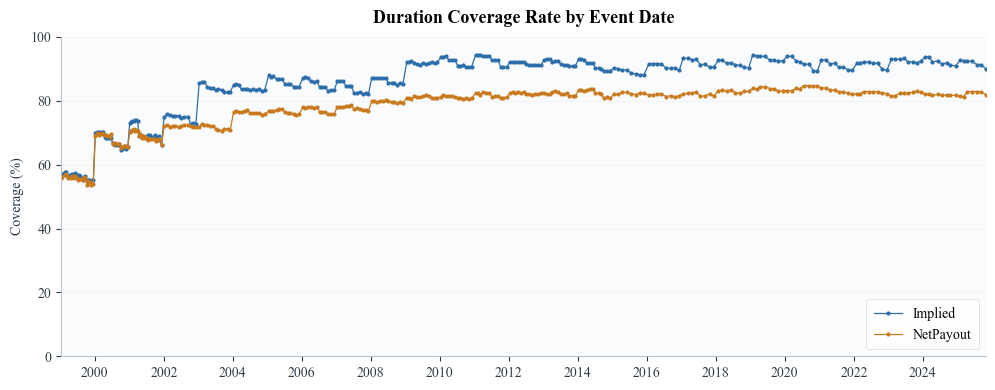

In [3]:
# Coverage diagnostic: share of event-firm obs with a valid duration
# Both Implied and NetPayout are annual → matched by year_pred = event_year - 1

cov_evt = df_evt[['event_date', 'date', 'firm_id', 'year_pred']].copy()
cov_evt['year_pred_int'] = pd.to_numeric(cov_evt['year_pred'], errors='coerce')

# Implied coverage
imp_yr = df_imp[['firm_id', 'year', 'implied_duration']].copy()
imp_yr['year'] = pd.to_numeric(imp_yr['year'], errors='coerce')
cov_evt = cov_evt.merge(
    imp_yr.rename(columns={'implied_duration': 'Duration_Implied'}),
    left_on=['firm_id', 'year_pred_int'],
    right_on=['firm_id', 'year'],
    how='left',
).drop(columns=['year'], errors='ignore')

# NetPayout coverage (same annual merge)
np_dur_col_cov = first_existing(
    df_np,
    ['Duration_NetPayout', 'Duration_NP', 'Duration_NetPayout_trim', 'Duration_NP_trim'],
    required=False, label='NetPayout duration for coverage'
)
if np_dur_col_cov:
    np_yr = df_np[['firm_id', 'year', np_dur_col_cov]].copy()
    np_yr['year'] = pd.to_numeric(np_yr['year'], errors='coerce')
    np_yr = np_yr.rename(columns={np_dur_col_cov: 'Duration_NetPayout'})
    cov_evt = cov_evt.merge(
        np_yr[['firm_id', 'year', 'Duration_NetPayout']],
        left_on=['firm_id', 'year_pred_int'],
        right_on=['firm_id', 'year'],
        how='left',
    ).drop(columns=['year'], errors='ignore')
else:
    cov_evt['Duration_NetPayout'] = np.nan

# Overall coverage summary
n = len(cov_evt)
cov_summary = pd.DataFrame({
    'Duration': ['Duration_Implied', 'Duration_NetPayout'],
    'N covered': [int(cov_evt['Duration_Implied'].notna().sum()),
                  int(cov_evt['Duration_NetPayout'].notna().sum())],
    'N total': [n, n],
    'Coverage %': [100 * cov_evt['Duration_Implied'].notna().mean(),
                   100 * cov_evt['Duration_NetPayout'].notna().mean()],
})
display(cov_summary.round(1))

# Coverage by event date
cov_by_event = (
    cov_evt.groupby('event_date', as_index=False)[['Duration_Implied', 'Duration_NetPayout']]
    .agg(lambda s: s.notna().mean())
    .sort_values('event_date')
    .dropna(subset=['event_date'])
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cov_by_event['event_date'], cov_by_event['Duration_Implied'] * 100,
        marker='o', markersize=2.0, linewidth=0.9, label='Implied', color=COLORS['blue'])
ax.plot(cov_by_event['event_date'], cov_by_event['Duration_NetPayout'] * 100,
        marker='o', markersize=2.0, linewidth=0.9, label='NetPayout', color=COLORS['orange'])
ax.set_title('Duration Coverage Rate by Event Date')
ax.set_ylabel('Coverage (%)')
ax.set_ylim(0, 100)
style_axes(ax, grid_axis='y', grid_alpha=0.25)
style_time_axis(ax, x_min=cov_by_event['event_date'].min(),
                x_max=cov_by_event['event_date'].max(),
                x_ticks=cov_by_event['event_date'], date_fmt='%Y')
style_legend(ax, loc='lower right')
plt.tight_layout()
fig.savefig(GRAPH_DIR / 'duration_coverage_by_event.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Define key variables

In [4]:
# ── Implied duration: annual firm-year panel → merge by firm_id + year_pred ──
# Also pull all robustness variants (dur_A_CAPM_r, dur_B_dss_approx, ...)
_imp_rob_cols = [c for c in df_imp.columns if c.startswith('dur_')]
imp_feat = df_imp[['firm_id', 'year', 'implied_duration'] + _imp_rob_cols].copy()
imp_feat['year'] = pd.to_numeric(imp_feat['year'], errors='coerce')
imp_feat['Duration_Implied'] = pd.to_numeric(imp_feat['implied_duration'], errors='coerce')

# Rename dur_X → Duration_Implied_X for clarity in df_evt
_imp_rename = {c: f'Duration_Implied_{c[4:]}' for c in _imp_rob_cols}
imp_feat = imp_feat.rename(columns=_imp_rename)
_imp_variant_cols = list(_imp_rename.values())
imp_feat = imp_feat[['firm_id', 'year', 'Duration_Implied'] + _imp_variant_cols].dropna(subset=['Duration_Implied']).copy()

df_evt['_year_pred_int'] = pd.to_numeric(df_evt['year_pred'], errors='coerce')
df_evt = df_evt.merge(
    imp_feat,
    left_on=['firm_id', '_year_pred_int'],
    right_on=['firm_id', 'year'],
    how='left',
).drop(columns=['year', '_year_pred_int'], errors='ignore')
print(f"Implied duration variants merged: {['Duration_Implied'] + _imp_variant_cols}")

# ── NetPayout duration: same annual firm-year merge (mirrors implied) ─────────
np_dur_col = first_existing(
    df_np,
    ['Duration_NetPayout', 'Duration_NP', 'Duration_NetPayout_trim', 'Duration_NP_trim', 'NP_Duration'],
    required=True,
    label='NetPayout duration'
)
np_feat = df_np[['firm_id', 'year', np_dur_col]].copy()
np_feat['year'] = pd.to_numeric(np_feat['year'], errors='coerce')
np_feat['Duration_NetPayout'] = pd.to_numeric(np_feat[np_dur_col], errors='coerce')
np_feat = np_feat[['firm_id', 'year', 'Duration_NetPayout']].dropna(subset=['Duration_NetPayout']).copy()

df_evt['_year_pred_int'] = pd.to_numeric(df_evt['year_pred'], errors='coerce')
df_evt = df_evt.merge(
    np_feat,
    left_on=['firm_id', '_year_pred_int'],
    right_on=['firm_id', 'year'],
    how='left',
).drop(columns=['year', '_year_pred_int'], errors='ignore')
print(f"NetPayout duration merged: Duration_NetPayout")

# ── Controls: beta, log_mcap, leverage from df_np (quarterly, strict-quarter) ─
np_ctrl = df_np.copy()
np_ctrl_date_col = first_existing(np_ctrl, ['date', 'effective_date', 'asof_effective_date', 'formation_date'], required=False, label='NetPayout date')
if np_ctrl_date_col:
    np_ctrl = np_ctrl.rename(columns={np_ctrl_date_col: 'asof_effective_date'})
    np_ctrl['asof_effective_date'] = pd.to_datetime(np_ctrl['asof_effective_date'], errors='coerce')
    if 'beta' in np_ctrl.columns:
        np_ctrl['beta'] = pd.to_numeric(np_ctrl['beta'], errors='coerce')
    mcap_col = first_existing(np_ctrl, ['mcap_eur', 'mcap', 'market_cap'], required=False, label='market cap')
    if mcap_col:
        np_ctrl['log_mcap'] = np.log(pd.to_numeric(np_ctrl[mcap_col], errors='coerce').clip(lower=1e-6))
    lev_col = first_existing(np_ctrl, ['leverage', 'lev', 'debt_ratio'], required=False, label='leverage')
    if lev_col and lev_col != 'leverage':
        np_ctrl['leverage'] = pd.to_numeric(np_ctrl[lev_col], errors='coerce')

    _ctrl_cols = [c for c in ['beta', 'log_mcap', 'leverage'] if c in np_ctrl.columns]
    for _col in _ctrl_cols:
        df_evt, _ = merge_strict_quarter_feature(
            df_evt,
            np_ctrl[['firm_id', 'asof_effective_date', _col]].dropna(subset=[_col]),
            _col,
            event_date_col='date',
            feature_date_col='asof_effective_date',
            key_priority=('firm_id',),
        )
    print(f"Controls merged (quarterly): {_ctrl_cols}")

print(f"df_evt shape: {df_evt.shape}")

Implied duration variants merged: ['Duration_Implied', 'Duration_Implied_A_CAPM_r', 'Duration_Implied_B_dss_approx', 'Duration_Implied_C_rho_roe_hi', 'Duration_Implied_C_rho_roe_lo', 'Duration_Implied_D_rho_g_hi', 'Duration_Implied_D_rho_g_lo', 'Duration_Implied_E_gbar_emp', 'Duration_Implied_F_beg_fallback', 'Duration_Implied_H_tight_winsor']
NetPayout duration merged: Duration_NetPayout
Controls merged (quarterly): ['leverage']
df_evt shape: (151024, 34)


## 4. Standardize variables

In [5]:
def zscore_by_year(df, col, year_col='year_pred'):
    def _z(s):
        s = pd.to_numeric(s, errors='coerce')
        mu = s.mean(skipna=True)
        sd = s.std(skipna=True, ddof=0)
        if pd.isna(sd) or sd == 0:
            return pd.Series(np.nan, index=s.index)
        return (s - mu) / sd
    return df.groupby(year_col, dropna=False)[col].transform(_z)

std_map = {
    'Duration_Implied': 'Duration_Implied_std',
    'Duration_NetPayout': 'Duration_NetPayout_std',
    'beta': 'beta_std',
    'log_mcap': 'log_mcap_std',
    'leverage': 'leverage_std',
    'bm': 'bm_std',
}

# Auto-add all implied duration robustness variants
for vc in [c for c in df_evt.columns if c.startswith('Duration_Implied_') and not c.endswith('_std')]:
    std_map[vc] = vc + '_std'

for raw_col, std_col in std_map.items():
    if raw_col in df_evt.columns:
        df_evt[std_col] = zscore_by_year(df_evt, raw_col, year_col='year_pred')

std_cols_present = [c for c in std_map.values() if c in df_evt.columns]
display(df_evt[std_cols_present].describe().T[['mean', 'std', 'count']])

,mean,std,count
Duration_Implied_std,8.807221e-17,1.000004,126502.0
Duration_NetPayout_std,-8.636506e-17,1.000004,115839.0
beta_std,9.336386e-18,1.000003,146121.0
leverage_std,3.198842e-17,1.000015,33763.0
Duration_Implied_A_CAPM_r_std,8.807221e-17,1.000004,126502.0
Duration_Implied_B_dss_approx_std,2.426479e-16,1.000004,126502.0
Duration_Implied_C_rho_roe_hi_std,-6.290872e-17,1.000004,126502.0
Duration_Implied_C_rho_roe_lo_std,-8.268003e-17,1.000004,126502.0
Duration_Implied_D_rho_g_hi_std,-6.111133e-17,1.000004,126502.0
Duration_Implied_D_rho_g_lo_std,4.673219e-17,1.000004,126502.0


## 5. Define regression helper functions

In [6]:
def build_formula(depvar, duration_var, include_event_fe=False, include_raw_shocks=False, controls=None):
    controls = controls or []
    terms = [
        f'ShockMP:{duration_var}',
        f'ShockInfo:{duration_var}',
    ]
    if 'beta' in controls:
        terms += ['ShockMP:beta_std', 'ShockInfo:beta_std']
    if 'size' in controls:
        terms += ['ShockMP:log_mcap_std', 'ShockInfo:log_mcap_std']
    if 'leverage' in controls:
        terms += ['ShockMP:leverage_std', 'ShockInfo:leverage_std']
    if 'bm' in controls:
        terms += ['ShockMP:bm_std', 'ShockInfo:bm_std']
    if include_raw_shocks:
        terms += ['ShockMP', 'ShockInfo']
    if include_event_fe:
        terms += ['C(event_date)']
    rhs = ' + '.join(terms)
    return f'{depvar} ~ 0 + {rhs}', terms

def _safe_get(series, key):
    return float(series[key]) if key in series.index else np.nan

def _cluster_groups(df, cluster='event'):
    if cluster == 'twoway' and 'firm_id' in df.columns:
        return np.column_stack([pd.Categorical(df['event_date']).codes, pd.Categorical(df['firm_id']).codes])
    return pd.Categorical(df['event_date']).codes

def _clean_controls_label(controls):
    if not controls:
        return 'None'
    label_map = {'beta': 'beta', 'size': 'size', 'leverage': 'leverage', 'bm': 'bm'}
    return ', '.join(label_map[c] for c in controls if c in label_map)

def _sig_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.01:
        return '***'
    if p < 0.05:
        return '**'
    if p < 0.10:
        return '*'
    return ''

def _coef_term(shock_name, duration_var):
    return f'{shock_name}:{duration_var}'

def run_regression(df, depvar, duration_var, specification_name, include_event_fe=False, include_raw_shocks=False, controls=None, cluster='event'):
    controls = controls or []
    formula, terms = build_formula(
        depvar=depvar,
        duration_var=duration_var,
        include_event_fe=include_event_fe,
        include_raw_shocks=include_raw_shocks,
        controls=controls,
    )

    needed = [depvar, 'ShockMP', 'ShockInfo', duration_var, 'event_date', 'firm_id']
    if 'beta' in controls:
        needed.append('beta_std')
    if 'size' in controls:
        needed.append('log_mcap_std')
    if 'leverage' in controls:
        needed.append('leverage_std')
    if 'bm' in controls:
        needed.append('bm_std')

    work = df[[c for c in needed if c in df.columns]].dropna().copy()
    if work.empty:
        return None

    model = smf.ols(formula=formula, data=work)
    groups = _cluster_groups(work, cluster=cluster)
    res = model.fit(cov_type='cluster', cov_kwds={'groups': groups})

    mp_term = _coef_term('ShockMP', duration_var)
    info_term = _coef_term('ShockInfo', duration_var)
    beta_mp = 'ShockMP:beta_std'
    beta_info = 'ShockInfo:beta_std'
    size_mp = 'ShockMP:log_mcap_std'
    size_info = 'ShockInfo:log_mcap_std'
    lev_mp = 'ShockMP:leverage_std'
    lev_info = 'ShockInfo:leverage_std'

    row = {
        'depvar': depvar,
        'duration_name': duration_var,
        'specification_name': specification_name,
        'event_FE': 'Yes' if include_event_fe else 'No',
        'controls': _clean_controls_label(controls),
        'coef_mp_duration': _safe_get(res.params, mp_term),
        'se_mp_duration': _safe_get(res.bse, mp_term),
        't_mp_duration': _safe_get(res.tvalues, mp_term),
        'p_mp_duration': _safe_get(res.pvalues, mp_term),
        'coef_info_duration': _safe_get(res.params, info_term),
        'se_info_duration': _safe_get(res.bse, info_term),
        't_info_duration': _safe_get(res.tvalues, info_term),
        'p_info_duration': _safe_get(res.pvalues, info_term),
        'coef_mp_beta': _safe_get(res.params, beta_mp),
        'coef_info_beta': _safe_get(res.params, beta_info),
        'coef_mp_size': _safe_get(res.params, size_mp),
        'coef_info_size': _safe_get(res.params, size_info),
        'coef_mp_leverage': _safe_get(res.params, lev_mp),
        'coef_info_leverage': _safe_get(res.params, lev_info),
        'N': int(res.nobs),
        'n_events': int(work['event_date'].nunique()),
        'r_squared': float(res.rsquared) if hasattr(res, 'rsquared') else np.nan,
        'model_obj': res,
    }
    return row

def make_reader_entry(coef, t_stat, p):
    if pd.isna(coef):
        return ''
    return f'{coef:.4f}{_sig_stars(p)} ({t_stat:.2f})'

## 6. Estimate main models

In [7]:
depvars_main = [c for c in ['AR_0', 'AR_0_1'] if c in df_evt.columns]
duration_vars = [c for c in ['Duration_Implied_std', 'Duration_NetPayout_std'] if c in df_evt.columns]

controls_available = {
    'beta': 'beta_std' in df_evt.columns,
    'size': 'log_mcap_std' in df_evt.columns,
    'leverage': 'leverage_std' in df_evt.columns,
    'bm': 'bm_std' in df_evt.columns,
}

ctrl_beta = [c for c in ['beta'] if controls_available.get(c)]
ctrl_plus = [c for c in ['beta', 'size', 'leverage'] if controls_available.get(c)]

spec_grid = [
    {'name': 'Model 1: Basic two-shock interaction', 'event_fe': False, 'raw_shocks': False, 'controls': []},
    {'name': 'Model 2: + beta interactions', 'event_fe': False, 'raw_shocks': False, 'controls': ctrl_beta},
    {'name': 'Model 3: + size/leverage interactions (if available)', 'event_fe': False, 'raw_shocks': False, 'controls': ctrl_plus},
    {'name': 'Model 4: Event FE', 'event_fe': True, 'raw_shocks': False, 'controls': ctrl_plus},
    {'name': 'Model 5: No Event FE (+ raw shocks)', 'event_fe': False, 'raw_shocks': True, 'controls': ctrl_plus},
]

results = []
for dep in depvars_main:
    for dur in duration_vars:
        for spec in spec_grid:
            row = run_regression(
                df=df_evt,
                depvar=dep,
                duration_var=dur,
                specification_name=spec['name'],
                include_event_fe=spec['event_fe'],
                include_raw_shocks=spec['raw_shocks'],
                controls=spec['controls'],
                cluster='event',
            )
            if row is not None:
                results.append(row)

df_results = pd.DataFrame(results)
if df_results.empty:
    raise ValueError('No models estimated. Check data availability and variable merges.')

display(df_results[['depvar', 'duration_name', 'specification_name', 'event_FE', 'controls', 'N', 'n_events', 'r_squared']])

,depvar,duration_name,specification_name,event_FE,controls,N,n_events,r_squared
0,AR_0,Duration_Implied_std,Model 1: Basic two-shock interaction,No,None,126502,312,0.000079
1,AR_0,Duration_Implied_std,Model 2: + beta interactions,No,beta,126401,312,0.008304
2,AR_0,Duration_Implied_std,Model 3: + size/leverage interactions (if avai...,No,"beta, leverage",28686,311,0.008838
3,AR_0,Duration_Implied_std,Model 4: Event FE,Yes,"beta, leverage",28686,311,0.095736
4,AR_0,Duration_Implied_std,Model 5: No Event FE (+ raw shocks),No,"beta, leverage",28686,311,0.024969
5,AR_0,Duration_NetPayout_std,Model 1: Basic two-shock interaction,No,None,115839,312,0.000322
6,AR_0,Duration_NetPayout_std,Model 2: + beta interactions,No,beta,114284,312,0.007365
7,AR_0,Duration_NetPayout_std,Model 3: + size/leverage interactions (if avai...,No,"beta, leverage",26588,311,0.008069
8,AR_0,Duration_NetPayout_std,Model 4: Event FE,Yes,"beta, leverage",26588,311,0.108118
9,AR_0,Duration_NetPayout_std,Model 5: No Event FE (+ raw shocks),No,"beta, leverage",26588,311,0.024779


## 7. Estimate robustness models

In [8]:
robust_rows = []

# ── Placebo 1: Pre-event day (AR_lag1) ───────────────────────────────────────
if 'AR_lag1' in df_evt.columns:
    for dur in duration_vars:
        row = run_regression(
            df=df_evt,
            depvar='AR_lag1',
            duration_var=dur,
            specification_name='Placebo: Pre-event day (AR_lag1, Event FE)',
            include_event_fe=True,
            include_raw_shocks=False,
            controls=ctrl_plus,
            cluster='event',
        )
        if row is not None:
            robust_rows.append(row)
else:
    print('WARNING: AR_lag1 not found in df_evt — pre-event placebo skipped.')

# ── Placebo 2: 3-day window AR_m1_1 (includes event day) ─────────────────────
if 'AR_m1_1' in df_evt.columns:
    for dur in duration_vars:
        row = run_regression(
            df=df_evt,
            depvar='AR_m1_1',
            duration_var=dur,
            specification_name='Robustness: 3-day window AR_m1_1 (Event FE)',
            include_event_fe=True,
            include_raw_shocks=False,
            controls=ctrl_plus,
            cluster='event',
        )
        if row is not None:
            robust_rows.append(row)

# ── Two-way clustering ────────────────────────────────────────────────────────
for dep in depvars_main:
    for dur in duration_vars:
        row = run_regression(
            df=df_evt,
            depvar=dep,
            duration_var=dur,
            specification_name='Robustness: Model 4 with two-way clustering',
            include_event_fe=True,
            include_raw_shocks=False,
            controls=ctrl_plus,
            cluster='twoway',
        )
        if row is not None:
            robust_rows.append(row)

# ── Implied Duration specification robustness ─────────────────────────────────
# Run Model 4 (Event FE + controls) for each DSS robustness variant
_imp_variant_std_cols = sorted([
    c for c in df_evt.columns
    if c.startswith('Duration_Implied_') and c.endswith('_std')
])
print(f"\nTesting {len(_imp_variant_std_cols)} implied duration variants:")
for var_col in _imp_variant_std_cols:
    for dep in depvars_main:
        row = run_regression(
            df=df_evt,
            depvar=dep,
            duration_var=var_col,
            specification_name=f'DSS Variant: {var_col.replace("Duration_Implied_","").replace("_std","")}',
            include_event_fe=True,
            include_raw_shocks=False,
            controls=ctrl_plus,
            cluster='event',
        )
        if row is not None:
            robust_rows.append(row)

df_robust = pd.DataFrame(robust_rows)
if not df_robust.empty:
    display(df_robust[['depvar', 'duration_name', 'specification_name', 'N', 'n_events',
                        'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
                        'coef_info_duration', 't_info_duration', 'p_info_duration']])

    # Summary table for DSS variants only
    dss_rob = df_robust[df_robust['specification_name'].str.startswith('DSS Variant')].copy()
    if not dss_rob.empty:
        print("\n── DSS Specification Robustness (Model 4, Event FE) ──")
        display(dss_rob[['depvar', 'duration_name', 'N',
                          'coef_mp_duration', 't_mp_duration',
                          'coef_info_duration', 't_info_duration']].round(4))
else:
    print('No robustness models estimated.')

/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning:


Testing 10 implied duration variants:


,depvar,duration_name,specification_name,N,n_events,coef_mp_duration,t_mp_duration,p_mp_duration,coef_info_duration,t_info_duration,p_info_duration
0,AR_lag1,Duration_Implied_std,"Placebo: Pre-event day (AR_lag1, Event FE)",28674,311,0.002091,0.513344,0.607711,-0.001863,-0.251837,0.801167
1,AR_lag1,Duration_NetPayout_std,"Placebo: Pre-event day (AR_lag1, Event FE)",26576,311,0.001130,0.190978,0.848543,-0.005972,-0.584003,0.559218
2,AR_m1_1,Duration_Implied_std,Robustness: 3-day window AR_m1_1 (Event FE),28360,310,0.002661,0.253202,0.800112,0.012001,0.846355,0.397355
3,AR_m1_1,Duration_NetPayout_std,Robustness: 3-day window AR_m1_1 (Event FE),26293,311,-0.006364,-0.692972,0.488327,0.009904,0.723603,0.469310
4,AR_0,Duration_Implied_std,Robustness: Model 4 with two-way clustering,28686,311,-0.002594,-0.406804,0.684152,0.011050,1.128976,0.258908
5,AR_0,Duration_NetPayout_std,Robustness: Model 4 with two-way clustering,26588,311,-0.011080,-1.987411,0.046877,0.013240,1.589815,0.111877
6,AR_0_1,Duration_Implied_std,Robustness: Model 4 with two-way clustering,28372,310,-0.000395,-0.044153,0.964783,0.016034,1.373055,0.169735
7,AR_0_1,Duration_NetPayout_std,Robustness: Model 4 with two-way clustering,26305,311,-0.008151,-1.255130,0.209432,0.018299,1.920825,0.054754
8,AR_0,Duration_Implied_A_CAPM_r_std,DSS Variant: A_CAPM_r,28686,311,-0.002594,-0.414840,0.678259,0.011050,1.094825,0.273594
9,AR_0_1,Duration_Implied_A_CAPM_r_std,DSS Variant: A_CAPM_r,28372,310,-0.000395,-0.045472,0.963731,0.016034,1.349962,0.177028



── DSS Specification Robustness (Model 4, Event FE) ──


,depvar,duration_name,N,coef_mp_duration,t_mp_duration,coef_info_duration,t_info_duration
8,AR_0,Duration_Implied_A_CAPM_r_std,28686,-0.0026,-0.4148,0.0111,1.0948
9,AR_0_1,Duration_Implied_A_CAPM_r_std,28372,-0.0004,-0.0455,0.0160,1.3500
10,AR_0,Duration_Implied_B_dss_approx_std,28686,-0.0013,-0.1968,0.0107,1.0078
11,AR_0_1,Duration_Implied_B_dss_approx_std,28372,0.0016,0.1818,0.0152,1.2896
12,AR_0,Duration_Implied_C_rho_roe_hi_std,28686,0.0016,0.2868,0.0073,0.7434
13,AR_0_1,Duration_Implied_C_rho_roe_hi_std,28372,0.0083,1.0261,0.0130,1.1384
14,AR_0,Duration_Implied_C_rho_roe_lo_std,28686,-0.0071,-1.0127,0.0146,1.4862
15,AR_0_1,Duration_Implied_C_rho_roe_lo_std,28372,-0.0103,-1.0470,0.0176,1.3514
16,AR_0,Duration_Implied_D_rho_g_hi_std,28686,-0.0021,-0.2358,0.0130,1.0911
17,AR_0_1,Duration_Implied_D_rho_g_hi_std,28372,-0.0031,-0.3116,0.0132,1.0338


## 8. Build tidy results tables

In [9]:
def _duration_label(x):
    return x.replace('_std', '').replace('Duration_', '')

tbl = df_results.copy()
tbl['Duration'] = tbl['duration_name'].map(_duration_label)
tbl['Specification'] = tbl['specification_name']
tbl['Event FE'] = tbl['event_FE']
tbl['Controls'] = tbl['controls']

fmt_cols = ['coef_mp_duration', 't_mp_duration', 'p_mp_duration', 'coef_info_duration', 't_info_duration', 'p_info_duration']
for c in fmt_cols:
    tbl[c] = pd.to_numeric(tbl[c], errors='coerce')

table_cols = [
    'Duration', 'Specification', 'Event FE', 'Controls',
    'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
    'coef_info_duration', 't_info_duration', 'p_info_duration',
    'N', 'n_events'
]

TABLE_A = (
    tbl[tbl['depvar'] == 'AR_0_1'][table_cols]
    .rename(columns={
        'coef_mp_duration': 'ShockMP × Duration',
        't_mp_duration': 't-stat MP',
        'p_mp_duration': 'p-value MP',
        'coef_info_duration': 'ShockInfo × Duration',
        't_info_duration': 't-stat Info',
        'p_info_duration': 'p-value Info',
        'n_events': 'Events',
    })
)

TABLE_B = (
    tbl[tbl['depvar'] == 'AR_0'][table_cols]
    .rename(columns={
        'coef_mp_duration': 'ShockMP × Duration',
        't_mp_duration': 't-stat MP',
        'p_mp_duration': 'p-value MP',
        'coef_info_duration': 'ShockInfo × Duration',
        't_info_duration': 't-stat Info',
        'p_info_duration': 'p-value Info',
        'n_events': 'Events',
    })
)

for _t in [TABLE_A, TABLE_B]:
    for c in ['ShockMP × Duration', 't-stat MP', 'p-value MP', 'ShockInfo × Duration', 't-stat Info', 'p-value Info']:
        _t[c] = _t[c].map(lambda v: f'{v:.4f}' if pd.notna(v) else '')

reader = tbl.copy()
reader['ShockMP × Duration'] = reader.apply(lambda r: make_reader_entry(r['coef_mp_duration'], r['t_mp_duration'], r['p_mp_duration']), axis=1)
reader['ShockInfo × Duration'] = reader.apply(lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], r['p_info_duration']), axis=1)
TABLE_READER = reader[['depvar', 'Duration', 'Specification', 'Event FE', 'Controls', 'ShockMP × Duration', 'ShockInfo × Duration', 'N', 'n_events']].rename(columns={'depvar': 'Return window', 'n_events': 'Events'})

print('TABLE A: Main results for AR_0_1')
display(TABLE_A)
print('TABLE B: Main results for AR_0')
display(TABLE_B)
print('Reader table (coef*** (t-stat))')
display(TABLE_READER)

TABLE A: Main results for AR_0_1


,Duration,Specification,Event FE,Controls,ShockMP × Duration,t-stat MP,p-value MP,ShockInfo × Duration,t-stat Info,p-value Info,N,Events
10,Implied,Model 1: Basic two-shock interaction,No,None,0.0038,0.4465,0.6552,0.0036,0.3657,0.7146,125693,312
11,Implied,Model 2: + beta interactions,No,beta,0.0010,0.1247,0.9008,0.0089,0.9364,0.3491,125595,312
12,Implied,Model 3: + size/leverage interactions (if avai...,No,"beta, leverage",0.0020,0.2296,0.8184,0.0155,1.2814,0.2000,28372,310
13,Implied,Model 4: Event FE,Yes,"beta, leverage",-0.0004,-0.0455,0.9637,0.0160,1.3500,0.1770,28372,310
14,Implied,Model 5: No Event FE (+ raw shocks),No,"beta, leverage",0.0010,0.1082,0.9139,0.0167,1.3986,0.1619,28372,310
15,NetPayout,Model 1: Basic two-shock interaction,No,None,-0.0030,-0.4486,0.6537,0.0134,1.8510,0.0642,115073,312
16,NetPayout,Model 2: + beta interactions,No,beta,-0.0042,-0.7276,0.4668,0.0132,2.0869,0.0369,113550,312
17,NetPayout,Model 3: + size/leverage interactions (if avai...,No,"beta, leverage",-0.0068,-1.0117,0.3117,0.0181,1.8051,0.0711,26305,311
18,NetPayout,Model 4: Event FE,Yes,"beta, leverage",-0.0082,-1.2589,0.2081,0.0183,1.8343,0.0666,26305,311
19,NetPayout,Model 5: No Event FE (+ raw shocks),No,"beta, leverage",-0.0081,-1.2359,0.2165,0.0188,1.8953,0.0581,26305,311


TABLE B: Main results for AR_0


,Duration,Specification,Event FE,Controls,ShockMP × Duration,t-stat MP,p-value MP,ShockInfo × Duration,t-stat Info,p-value Info,N,Events
0,Implied,Model 1: Basic two-shock interaction,No,None,0.0058,0.6473,0.5174,-0.0004,-0.0648,0.9484,126502,312
1,Implied,Model 2: + beta interactions,No,beta,0.0032,0.3757,0.7071,0.0045,0.6780,0.4978,126401,312
2,Implied,Model 3: + size/leverage interactions (if avai...,No,"beta, leverage",-0.0005,-0.0787,0.9372,0.0103,1.0143,0.3104,28686,311
3,Implied,Model 4: Event FE,Yes,"beta, leverage",-0.0026,-0.4148,0.6783,0.0111,1.0948,0.2736,28686,311
4,Implied,Model 5: No Event FE (+ raw shocks),No,"beta, leverage",-0.0021,-0.3268,0.7438,0.0115,1.1403,0.2542,28686,311
5,NetPayout,Model 1: Basic two-shock interaction,No,None,-0.0077,-1.6031,0.1089,0.0108,2.2128,0.0269,115839,312
6,NetPayout,Model 2: + beta interactions,No,beta,-0.0092,-2.2164,0.0267,0.0103,2.3762,0.0175,114284,312
7,NetPayout,Model 3: + size/leverage interactions (if avai...,No,"beta, leverage",-0.0098,-1.7050,0.0882,0.0115,1.3721,0.1700,26588,311
8,NetPayout,Model 4: Event FE,Yes,"beta, leverage",-0.0111,-1.9967,0.0459,0.0132,1.5974,0.1102,26588,311
9,NetPayout,Model 5: No Event FE (+ raw shocks),No,"beta, leverage",-0.0116,-2.1413,0.0322,0.0126,1.5341,0.1250,26588,311


Reader table (coef*** (t-stat))


,Return window,Duration,Specification,Event FE,Controls,ShockMP × Duration,ShockInfo × Duration,N,Events
0,AR_0,Implied,Model 1: Basic two-shock interaction,No,None,0.0058 (0.65),-0.0004 (-0.06),126502,312
1,AR_0,Implied,Model 2: + beta interactions,No,beta,0.0032 (0.38),0.0045 (0.68),126401,312
2,AR_0,Implied,Model 3: + size/leverage interactions (if avai...,No,"beta, leverage",-0.0005 (-0.08),0.0103 (1.01),28686,311
3,AR_0,Implied,Model 4: Event FE,Yes,"beta, leverage",-0.0026 (-0.41),0.0111 (1.09),28686,311
4,AR_0,Implied,Model 5: No Event FE (+ raw shocks),No,"beta, leverage",-0.0021 (-0.33),0.0115 (1.14),28686,311
5,AR_0,NetPayout,Model 1: Basic two-shock interaction,No,None,-0.0077 (-1.60),0.0108** (2.21),115839,312
6,AR_0,NetPayout,Model 2: + beta interactions,No,beta,-0.0092** (-2.22),0.0103** (2.38),114284,312
7,AR_0,NetPayout,Model 3: + size/leverage interactions (if avai...,No,"beta, leverage",-0.0098* (-1.71),0.0115 (1.37),26588,311
8,AR_0,NetPayout,Model 4: Event FE,Yes,"beta, leverage",-0.0111** (-2.00),0.0132 (1.60),26588,311
9,AR_0,NetPayout,Model 5: No Event FE (+ raw shocks),No,"beta, leverage",-0.0116** (-2.14),0.0126 (1.53),26588,311


## 8b. Side-by-side comparison tables

In [10]:
compact = tbl[['depvar', 'duration_name', 'specification_name', 'event_FE', 'coef_mp_duration', 'coef_info_duration', 't_mp_duration', 't_info_duration']].copy()
compact['mp_reader'] = compact.apply(lambda r: make_reader_entry(r['coef_mp_duration'], r['t_mp_duration'], np.nan), axis=1)
compact['info_reader'] = compact.apply(lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], np.nan), axis=1)

# Comparison 1: Implied vs NetPayout (same return window, same specification)
CMP_1 = (
    compact[compact['depvar'] == 'AR_0_1']
    .pivot_table(index=['depvar', 'specification_name', 'event_FE'], columns='duration_name', values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# Comparison 2: AR_0 vs AR_0_1 (same duration, same specification)
CMP_2 = (
    compact[compact['depvar'].isin(['AR_0', 'AR_0_1'])]
    .pivot_table(index=['duration_name', 'specification_name', 'event_FE'], columns='depvar', values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# Comparison 3: Event FE vs No Event FE (same duration, same return window; focus on Model 4 vs Model 5)
cmp3_base = compact[compact['specification_name'].isin(['Model 4: Event FE', 'Model 5: No Event FE (+ raw shocks)'])].copy()
CMP_3 = (
    cmp3_base
    .pivot_table(index=['depvar', 'duration_name'], columns='specification_name', values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

print('Comparison Table 1: Implied vs NetPayout')
display(CMP_1)
print('Comparison Table 2: AR_0 vs AR_0_1')
display(CMP_2)
print('Comparison Table 3: Event FE vs No Event FE')
display(CMP_3)

Comparison Table 1: Implied vs NetPayout


info_reader                                   mp_reader                       
duration_name                                                      Duration_Implied_std Duration_NetPayout_std Duration_Implied_std Duration_NetPayout_std
depvar specification_name                                 event_FE                                                                                        
AR_0_1 Model 1: Basic two-shock interaction               No              0.0036 (0.37)          0.0134 (1.85)        0.0038 (0.45)        -0.0030 (-0.45)
       Model 2: + beta interactions                       No              0.0089 (0.94)          0.0132 (2.09)        0.0010 (0.12)        -0.0042 (-0.73)
       Model 3: + size/leverage interactions (if avail... No              0.0155 (1.28)          0.0181 (1.81)        0.0020 (0.23)        -0.0068 (-1.01)
       Model 4: Event FE                                  Yes             0.0160 (1.35)          0.0183 (1.83)      -0.0004 (-0.05)        -0.0082 (-1.26)
       Model 5: No Event FE (+ raw shocks)                No              0.0167 (1.40)          0.0188 (1.90)        0.0010 (0.11)        -0.0081 (-1.24)

Comparison Table 2: AR_0 vs AR_0_1


info_reader                       mp_reader                 
depvar                                                                                         AR_0         AR_0_1             AR_0           AR_0_1
duration_name          specification_name                                 event_FE                                                                  
Duration_Implied_std   Model 1: Basic two-shock interaction               No        -0.0004 (-0.06)  0.0036 (0.37)    0.0058 (0.65)    0.0038 (0.45)
                       Model 2: + beta interactions                       No          0.0045 (0.68)  0.0089 (0.94)    0.0032 (0.38)    0.0010 (0.12)
                       Model 3: + size/leverage interactions (if avail... No          0.0103 (1.01)  0.0155 (1.28)  -0.0005 (-0.08)    0.0020 (0.23)
                       Model 4: Event FE                                  Yes         0.0111 (1.09)  0.0160 (1.35)  -0.0026 (-0.41)  -0.0004 (-0.05)
                       Model 5: No Event FE (+ raw shocks)                No          0.0115 (1.14)  0.0167 (1.40)  -0.0021 (-0.33)    0.0010 (0.11)
Duration_NetPayout_std Model 1: Basic two-shock interaction               No          0.0108 (2.21)  0.0134 (1.85)  -0.0077 (-1.60)  -0.0030 (-0.45)
                       Model 2: + beta interactions                       No          0.0103 (2.38)  0.0132 (2.09)  -0.0092 (-2.22)  -0.0042 (-0.73)
                       Model 3: + size/leverage interactions (if avail... No          0.0115 (1.37)  0.0181 (1.81)  -0.0098 (-1.71)  -0.0068 (-1.01)
                       Model 4: Event FE                                  Yes         0.0132 (1.60)  0.0183 (1.83)  -0.0111 (-2.00)  -0.0082 (-1.26)
                       Model 5: No Event FE (+ raw shocks)                No          0.0126 (1.53)  0.0188 (1.90)  -0.0116 (-2.14)  -0.0081 (-1.24)

Comparison Table 3: Event FE vs No Event FE


info_reader                                             mp_reader                                    
specification_name            Model 4: Event FE Model 5: No Event FE (+ raw shocks) Model 4: Event FE Model 5: No Event FE (+ raw shocks)
depvar duration_name                                                                                                                     
AR_0   Duration_Implied_std       0.0111 (1.09)                       0.0115 (1.14)   -0.0026 (-0.41)                     -0.0021 (-0.33)
       Duration_NetPayout_std     0.0132 (1.60)                       0.0126 (1.53)   -0.0111 (-2.00)                     -0.0116 (-2.14)
AR_0_1 Duration_Implied_std       0.0160 (1.35)                       0.0167 (1.40)   -0.0004 (-0.05)                       0.0010 (0.11)
       Duration_NetPayout_std     0.0183 (1.83)                       0.0188 (1.90)   -0.0082 (-1.26)                     -0.0081 (-1.24)

## 9. Create coefficient plots

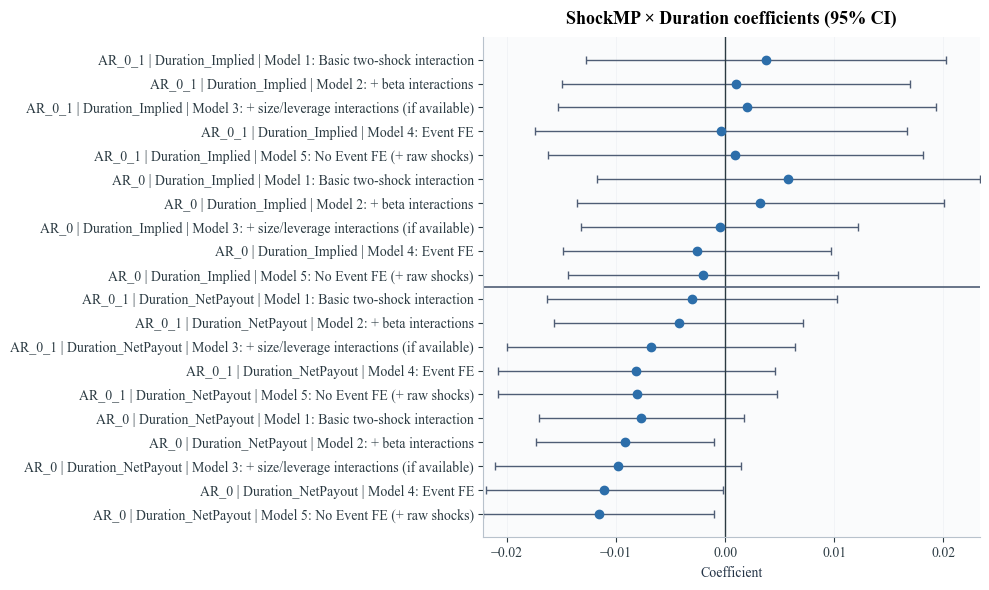

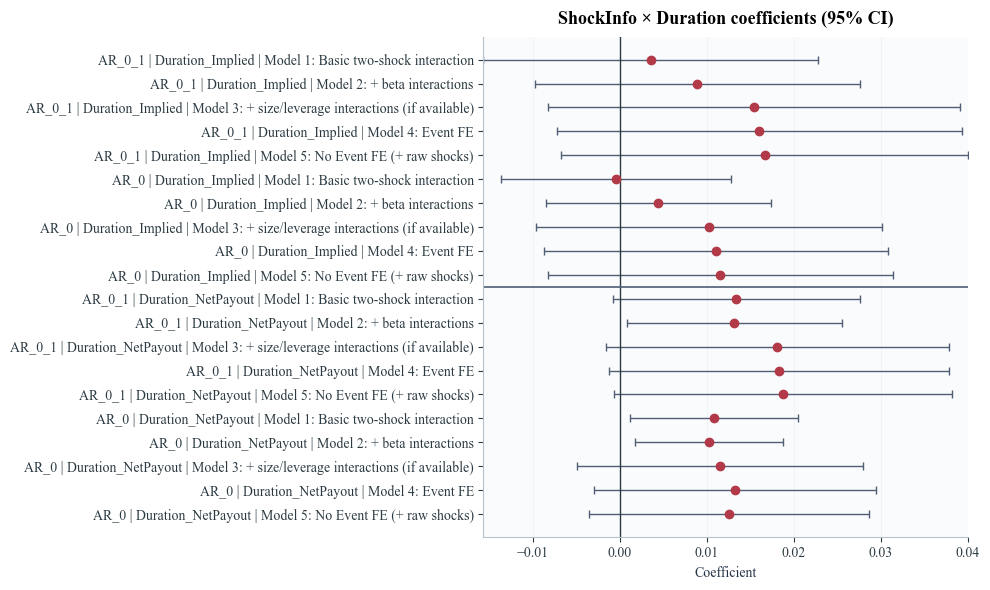

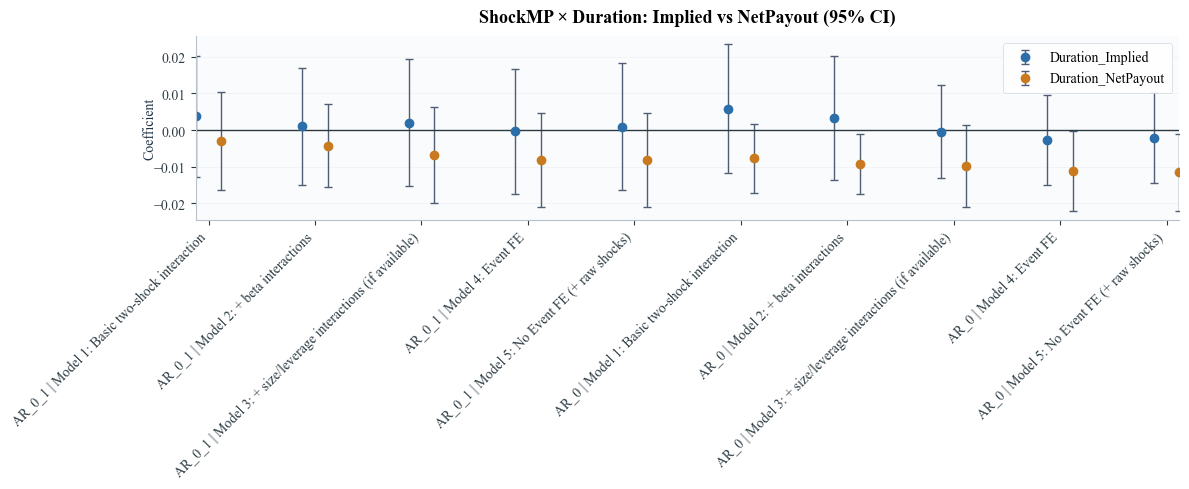

In [11]:
plot_df = df_results.copy()
plot_df['label'] = plot_df['depvar'] + ' | ' + plot_df['duration_name'].str.replace('_std', '', regex=False) + ' | ' + plot_df['specification_name']

duration_order_map = {
    'Duration_Implied_std': 0,
    'Duration_NetPayout_std': 1,
}
depvar_order_map = {
    'AR_0_1': 0,
    'AR_0': 1,
}
spec_order_map = {
    'Model 1: Basic two-shock interaction': 0,
    'Model 2: + beta interactions': 1,
    'Model 3: + size/leverage interactions (if available)': 2,
    'Model 4: Event FE': 3,
    'Model 5: No Event FE (+ raw shocks)': 4,
}

def coef_ci_ordered(df, coef_col, se_col):
    d = df[['label', 'duration_name', 'depvar', 'specification_name', coef_col, se_col]].dropna().copy()
    d['duration_order'] = d['duration_name'].map(duration_order_map).fillna(99)
    d['depvar_order'] = d['depvar'].map(depvar_order_map).fillna(99)
    d['spec_order'] = d['specification_name'].map(spec_order_map).fillna(99)
    d = d.sort_values(['duration_order', 'depvar_order', 'spec_order']).reset_index(drop=True)
    d['lo'] = d[coef_col] - 1.96 * d[se_col]
    d['hi'] = d[coef_col] + 1.96 * d[se_col]
    return d

# Plot 1: ShockMP x Duration
p1 = coef_ci_ordered(plot_df, 'coef_mp_duration', 'se_mp_duration')
fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(p1))))
y = np.arange(len(p1))
ax.errorbar(
    p1['coef_mp_duration'],
    y,
    xerr=1.96 * p1['se_mp_duration'],
    fmt='o',
    color=COLORS['blue'],
    ecolor=COLORS['neutral'],
    capsize=3,
)
ax.axvline(0, color=COLORS['reference'], linewidth=1)

if p1['duration_name'].eq('Duration_Implied_std').any() and p1['duration_name'].eq('Duration_NetPayout_std').any():
    split_idx = int(p1['duration_name'].eq('Duration_Implied_std').sum())
    ax.axhline(split_idx - 0.5, color=COLORS['neutral'], linewidth=1.2)

ax.set_yticks(y)
ax.set_yticklabels(p1['label'])
ax.invert_yaxis()
ax.set_title('ShockMP × Duration coefficients (95% CI)')
ax.set_xlabel('Coefficient')
style_axes(ax, grid_axis='x', grid_alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 2: ShockInfo x Duration
p2 = coef_ci_ordered(plot_df, 'coef_info_duration', 'se_info_duration')
fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(p2))))
y = np.arange(len(p2))
ax.errorbar(
    p2['coef_info_duration'],
    y,
    xerr=1.96 * p2['se_info_duration'],
    fmt='o',
    color=COLORS['accent'],
    ecolor=COLORS['neutral'],
    capsize=3,
)
ax.axvline(0, color=COLORS['reference'], linewidth=1)

if p2['duration_name'].eq('Duration_Implied_std').any() and p2['duration_name'].eq('Duration_NetPayout_std').any():
    split_idx = int(p2['duration_name'].eq('Duration_Implied_std').sum())
    ax.axhline(split_idx - 0.5, color=COLORS['neutral'], linewidth=1.2)

ax.set_yticks(y)
ax.set_yticklabels(p2['label'])
ax.invert_yaxis()
ax.set_title('ShockInfo × Duration coefficients (95% CI)')
ax.set_xlabel('Coefficient')
style_axes(ax, grid_axis='x', grid_alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 3: side-by-side Implied vs NetPayout
p3 = plot_df[plot_df['duration_name'].isin(['Duration_Implied_std', 'Duration_NetPayout_std'])].copy()
p3['depvar_order'] = p3['depvar'].map(depvar_order_map).fillna(99)
p3['spec_order'] = p3['specification_name'].map(spec_order_map).fillna(99)
p3 = p3.sort_values(['depvar_order', 'spec_order', 'duration_name'])
base_labels = p3[['depvar', 'specification_name', 'depvar_order', 'spec_order']].drop_duplicates().sort_values(['depvar_order', 'spec_order']).reset_index(drop=True)
base_labels['x'] = np.arange(len(base_labels))
p3 = p3.merge(base_labels[['depvar', 'specification_name', 'x']], on=['depvar', 'specification_name'], how='left')

fig, ax = plt.subplots(figsize=(12, 5))
for dur, offset, color in [
    ('Duration_Implied_std', -0.12, COLORS['blue']),
    ('Duration_NetPayout_std', 0.12, COLORS['orange']),
]:
    d = p3[p3['duration_name'] == dur]
    ax.errorbar(
        d['x'] + offset,
        d['coef_mp_duration'],
        yerr=1.96 * d['se_mp_duration'],
        fmt='o',
        color=color,
        ecolor=COLORS['neutral'],
        capsize=3,
        label=dur.replace('_std', ''),
    )

ax.axhline(0, color=COLORS['reference'], linewidth=1)
ax.set_xticks(base_labels['x'])
ax.set_xticklabels(base_labels['depvar'] + ' | ' + base_labels['specification_name'], rotation=45, ha='right')
ax.set_title('ShockMP × Duration: Implied vs NetPayout (95% CI)')
ax.set_ylabel('Coefficient')
style_axes(ax, grid_axis='y', grid_alpha=0.25)
style_legend(ax, loc='best')
plt.tight_layout()
plt.show()

## 10. Export output tables

In [12]:
# Wald tests: H0 beta(ShockMP x Duration) = beta(ShockInfo x Duration)
wald_rows = []
for _, r in df_results.iterrows():
    res = r['model_obj']
    dur = r['duration_name']
    mp_term = f'ShockMP:{dur}'
    info_term = f'ShockInfo:{dur}'
    if mp_term not in res.params.index or info_term not in res.params.index:
        continue

    R = np.zeros((1, len(res.params)))
    names = list(res.params.index)
    R[0, names.index(mp_term)] = 1.0
    R[0, names.index(info_term)] = -1.0
    wt = res.wald_test(R, scalar=True)

    beta_mp = float(res.params[mp_term])
    beta_info = float(res.params[info_term])
    wald_rows.append({
        'Duration': dur.replace('_std', '').replace('Duration_', ''),
        'Return window': r['depvar'],
        'Specification': r['specification_name'],
        'beta_MP': beta_mp,
        'beta_Info': beta_info,
        'difference': beta_mp - beta_info,
        'Wald p-value': float(wt.pvalue),
    })

regression_results_main = df_results.drop(columns=['model_obj']).copy()
regression_results_reader = TABLE_READER.copy()
regression_results_wald = pd.DataFrame(wald_rows)

TABLE_DIR.mkdir(parents=True, exist_ok=True)
regression_results_main.to_csv(TABLE_DIR / 'regression_results_main.csv', index=False)
regression_results_reader.to_csv(TABLE_DIR / 'regression_results_reader.csv', index=False)
regression_results_wald.to_csv(TABLE_DIR / 'regression_results_wald.csv', index=False)

# Optional LaTeX export
latex_cols = [
    'depvar', 'duration_name', 'specification_name', 'event_FE', 'controls',
    'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
    'coef_info_duration', 't_info_duration', 'p_info_duration',
    'N', 'n_events', 'r_squared'
]
regression_results_main[latex_cols].to_latex(TABLE_DIR / 'regression_results_main.tex', index=False, float_format='%.4f')

print('Exported:')
print(TABLE_DIR / 'regression_results_main.csv')
print(TABLE_DIR / 'regression_results_reader.csv')
print(TABLE_DIR / 'regression_results_wald.csv')
print(TABLE_DIR / 'regression_results_main.tex')

Exported:
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_main.csv
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_reader.csv
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_wald.csv
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_main.tex


## Interpretation Notes

- `ShockMP × Duration`: under tightening surprises, a more negative coefficient is consistent with stronger losses for long-duration equities.
- `ShockInfo × Duration`: sign is ambiguous a priori because information shocks can combine discount-rate and cash-flow effects.
- Event FE models isolate within-event cross-sectional variation across firms.
- No Event FE models additionally use cross-event variation in shock magnitudes.